### Exploring the correlation between the number and ratio of things to do around a listing with price and rating

In [ ]:
import pandas as pd
import osmnx as ox
import geopandas as gpd
import time
import winsound as ws
import os

#load the cleaned dataset into memory
air = pd.read_csv("./Airbnb Data/updated_listing.csv", encoding="latin1")
cols = ["listing_id", "city"]
cities = air[cols]["city"].dropna().unique()
print(cities)


['Paris' 'New York' 'Rio de Janeiro' 'Sydney' 'Rome' 'Istanbul'
 'Cape Town' 'Mexico City' 'Hong Kong' 'Bangkok']


### Testing a single query

In [ ]:

query = "paris"
tags1 = {
    "amenity": ["bar", "cafe", "fast_food", "food_court", "ice_cream", "pub", "restaurant",
                "arts_centre", "brothel", "casino", "cinema", "community_centre", "conference_centre",
                "events_venue","exhibition_centre","fountain","gambling","love_hotel","music_venue",
                "nightclub","planetarium","social_centre","stage","stripclub","studio","swingerclub"
                "theatre", "atm", "bank", "money_transfer"],
    "leisure": True,
    "tourism": True,
}
tags2 = {
    "historic": True,
    "public_transport": True
}

#split the queries to prevent timeout
gdf = ox.geocode_to_gdf("Paris, France")
place = ox.features_from_polygon(gdf.geometry.iloc[0], tags1)
time.sleep(10)
place2 = ox.features_from_polygon(gdf.geometry.iloc[0], tags2)


In [ ]:
cPlace = pd.concat([place, place2])

#AI used to filter for duplicates in the geodataframe
##AI start
# 1. Separate the single table into Points and Polygons
# OSMnx puts 'Point' in the geometry column for nodes
points = cPlace[cPlace.geometry.type == 'Point'].copy()
polygons = cPlace[cPlace.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()

# 2. Find points that are INSIDE any polygon
# 'predicate="within"' finds points physically located inside an area
duplicates = points.sjoin(polygons, predicate='within', how='inner')

# 3. Filter: Only count as a duplicate if the Names match
# This prevents deleting a "Bench" node inside a "Park" polygon
actual_dupes_indices = duplicates[duplicates['name_left'] == duplicates['name_right']].index

# 4. Remove those specific points from the original table
gdf = cPlace.drop(actual_dupes_indices)


print(f"Cleaned {len(actual_dupes_indices)} duplicate points from the table.")
##AI end

display(gdf[gdf['name'].notna()])

Cleaned 229 duplicate points from the table.


geometry  \
element id                                                              
node    130102845                            POINT (2.31188 48.85704)   
        158603712                            POINT (2.32287 48.82984)   
        175539450                            POINT (2.32453 48.83199)   
        191031796                             POINT (2.34879 48.8534)   
        224711659                            POINT (2.31558 48.84031)   
...                                                               ...   
way     1383547261  POLYGON ((2.401 48.84404, 2.40111 48.84404, 2....   
        1383547262  POLYGON ((2.40079 48.84404, 2.40089 48.84404, ...   
        1455431379    LINESTRING (2.28242 48.84887, 2.28225 48.84897)   
        1463746821    LINESTRING (2.28572 48.83081, 2.28649 48.83132)   
        1463746822    LINESTRING (2.28563 48.83089, 2.28635 48.83138)   

                   description     tourism addr:city addr:housenumber  \
element id                                                              
node    130102845          NaN      museum     Paris              129   
        158603712          NaN         NaN       NaN              NaN   
        175539450          NaN         NaN       NaN                8   
        191031796          NaN  attraction       NaN              NaN   
        224711659          NaN       hotel       NaN              NaN   
...                        ...         ...       ...              ...   
way     1383547261         NaN         NaN       NaN              NaN   
        1383547262         NaN         NaN       NaN              NaN   
        1455431379         NaN         NaN       NaN              NaN   
        1463746821         NaN         NaN       NaN              NaN   
        1463746822         NaN         NaN       NaN              NaN   

                   addr:postcode      addr:street  \
element id                                          
node    130102845          75007  Rue de Grenelle   
        158603712            NaN              NaN   
        175539450          75014  Rue des Plantes   
        191031796            NaN              NaN   
        224711659            NaN              NaN   
...                          ...              ...   
way     1383547261           NaN              NaN   
        1383547262           NaN              NaN   
        1455431379           NaN              NaN   
        1463746821           NaN              NaN   
        1463746822           NaN              NaN   

                                                                  fee  \
element id                                                              
node    130102845   full:12;discount:10;free: under 26, handicap, ...   
        158603712                                                 NaN   
        175539450                                                 NaN   
        191031796                                                 NaN   
        224711659                                                 NaN   
...                                                               ...   
way     1383547261                                                NaN   
        1383547262                                                NaN   
        1455431379                                                NaN   
        1463746821                                                NaN   
        1463746822                                                NaN   

                                                    name      name:de  ...  \
element id                                                             ...   
node    130102845                       Musée de l'Armée  Armeemuseum  ...   
        158603712                   The Village Terrazza          NaN  ...   
        175539450                              Le Severo          NaN  ...   
        191031796        Point zéro des Routes de France          NaN  ...   
        224711659                                   I

### Get city data from all 10 cities
#### Creates a dict of geodataframes {city:gdf}

In [ ]:
places = {}
tags1 = {
    "amenity": ["bar", "cafe", "fast_food", "food_court", "ice_cream", "pub", "restaurant",
                "arts_centre", "brothel", "casino", "cinema", "community_centre", "conference_centre",
                "events_venue","exhibition_centre","fountain","gambling","love_hotel","music_venue",
                "nightclub","planetarium","social_centre","stage","stripclub","studio","swingerclub"
                "theatre", "atm", "bank", "money_transfer"],
    "leisure": True,
    "tourism": True,
}
tags2 = {
    "historic": True,
    "public_transport": True
}

#AI function from single query
def remove_dupes(place):
    # 1. Separate the single table into Points and Polygons
    # OSMnx puts 'Point' in the geometry column for nodes
    points = place[place.geometry.type == 'Point'].copy()
    polygons = place[place.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()

    # 2. Find points that are INSIDE any polygon
    # 'predicate="within"' finds points physically located inside an area
    duplicates = points.sjoin(polygons, predicate='within', how='inner')

    # 3. Filter: Only count as a duplicate if the Names match
    # This prevents deleting a "Bench" node inside a "Park" polygon
    actual_dupes_indices = duplicates[duplicates['name_left'] == duplicates['name_right']].index

    # 4. Remove those specific points from the original table
    gdf = place.drop(actual_dupes_indices)
    print(f"Cleaned {len(actual_dupes_indices)} duplicate points from the table.")
    return gdf


    

for location in cities:
    #Using 'Cape Town' as the location query fails to get the area
    if location == "Cape Town":
        location = "City of Cape Town"

    print("getting: ", location)
    #checks if the geo data is already downloaded to avoid the 
    #100 minute query time to get all cities if the data isn't cached
    if os.path.exists(f"./City Data/{location}.gpkg"):
        print("already saved")
        places[location] = gpd.read_file(f"./City Data/{location}.gpkg") #loads location into places to be used later
    else:
        #performs 2 separate queries then combines and saves them
        try:
            cols = ["geometry","amenity","tourism","leisure","historic","public_transport"]

            print("retriveing first query")
            Q1 = ox.features_from_place(location, tags1)
            time.sleep(10)

            print("retriveing second query")
            Q2 = ox.features_from_place(location, tags2)

            place = pd.concat([Q1,Q2])
            place = remove_dupes(place)
            place = place[cols]
            print("saving")
            place.to_file(f"./City Data/{location}.gpkg", driver="GPKG")

        except Exception as e:
            print(f"Error while getting {location} error: {e}")
            continue

        places[location] = place
        time.sleep(1)
#renames cape town back to original
places["Cape Town"] = places.pop("City of Cape Town")

getting:  Paris
already saved
getting:  New York
already saved
getting:  Rio de Janeiro
already saved
getting:  Sydney
already saved
getting:  Rome
already saved
getting:  Istanbul
already saved
getting:  City of Cape Town
already saved
getting:  Mexico City
already saved
getting:  Hong Kong
already saved
getting:  Bangkok
already saved


## Search for places within different radiuses for "walkability"
### Modified ai generated code

In [6]:
from sklearn.neighbors import BallTree
import numpy as np
import pandas as pd



def places_in_radius(radius_m):
    """
    Returns all places within a radius of all listings

    Args: 
        radius_m: search radius in meters
    Returns:
        Columns for counts of place types
    """
    results = []
    earth_radius = 6371000
    radius_rad = radius_m / earth_radius

    for city, city_places in places.items():

        listings_city = air[air["city"] == city]
        if listings_city.empty:
            continue

        listing_coords = np.radians(
            listings_city[["latitude", "longitude"]].values
        )

        #city places is the geodf with all the places (node, way, relation)
        city_places_points = city_places.copy()
        city_places_points["geometry"] = city_places_points.geometry.representative_point()
        
        city_result = listings_city[["listing_id"]].copy()

        for tag in ["amenity", "tourism", "leisure", "historic", "public_transport"]:

            #gets column for tag then whats not na
            tag_places = city_places_points[city_places_points[tag].notna()]

            if tag_places.empty:
                print(f"{tag} tag empty")
                city_result[f"{tag}_nearby_{radius_m}m"] = 0
                continue

            place_coords = np.radians(
                np.column_stack([
                    tag_places.geometry.y,
                    tag_places.geometry.x
                ])
            )
            tree = BallTree(place_coords, metric="haversine")

            counts = tree.query_radius(
                listing_coords,
                r=radius_rad,
                count_only=True
            )

            city_result[f"{tag}_nearby_{radius_m}m"] = counts

        results.append(city_result)

    combined_results = pd.concat(results, ignore_index=True)
    return combined_results

In [8]:
#this code relies on being run sequentially once so if you need to rerun this you need to run the 
#first cell again to reload air
results = []
print("getting radiuses")
for i in range(500,5500,500):
    print(i)
    results.append(places_in_radius(i))
print("combining")
combined_results = results[0]
for r in results[1:]:
    combined_results = combined_results.merge(r, on="listing_id", how="left")
air = air.merge(combined_results, on="listing_id", how="left")

getting radiuses
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
combining


In [9]:
tags = ["amenity", "tourism", "leisure", "historic", "public_transport"]
radii = range(500, 5500, 500)

for r in radii:
    # build list of columns for this radius
    cols = [f"{tag}_nearby_{r}m" for tag in tags if f"{tag}_nearby_{r}m" in air.columns]
    
    # total nearby for this radius
    air[f"total_nearby_{r}m"] = air[cols].sum(axis=1)
    
    # compute ratios for each tag
    for tag in tags:
        col = f"{tag}_nearby_{r}m"
        ratio_col = f"{tag}_ratio_{r}m"
        if col in air.columns:
            air[ratio_col] = air[col] / air[f"total_nearby_{r}m"]



### Data visualization

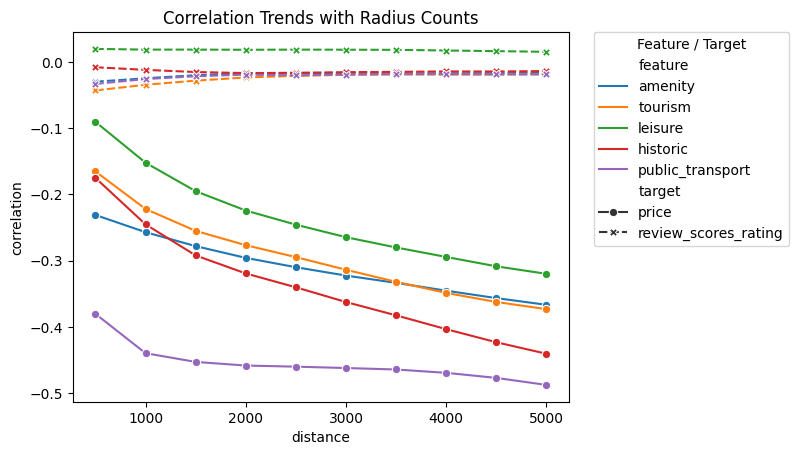

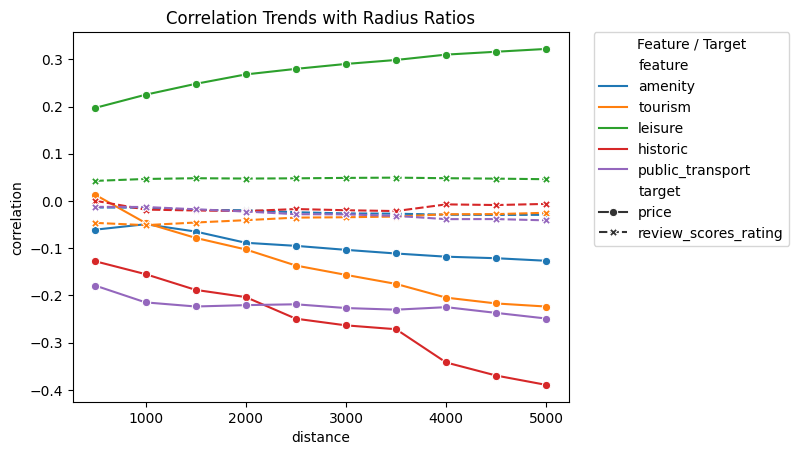

,price,review_scores_rating
price,1.000000,0.031316
review_scores_rating,0.031316,1.000000
review_scores_location,0.017611,0.542997
review_scores_value,0.011974,0.784566
amenity_nearby_500m,-0.230967,-0.029722
tourism_nearby_500m,-0.165268,-0.042937
leisure_nearby_500m,-0.090331,0.019751
historic_nearby_500m,-0.174980,-0.007907
public_transport_nearby_500m,-0.380242,-0.033059
amenity_ratio_500m,-0.060692,-0.013744


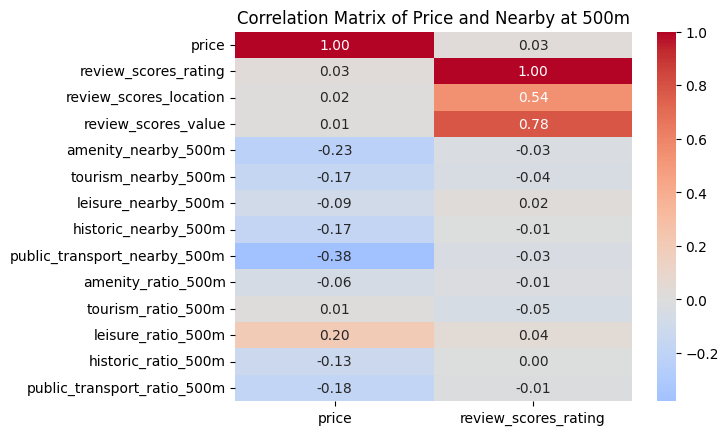

,price,review_scores_rating
price,1.000000,0.031316
review_scores_rating,0.031316,1.000000
review_scores_location,0.017611,0.542997
review_scores_value,0.011974,0.784566
amenity_nearby_1000m,-0.256903,-0.024586
tourism_nearby_1000m,-0.221865,-0.034327
leisure_nearby_1000m,-0.152040,0.018706
historic_nearby_1000m,-0.245089,-0.011885
public_transport_nearby_1000m,-0.439596,-0.025758
amenity_ratio_1000m,-0.049202,-0.014252


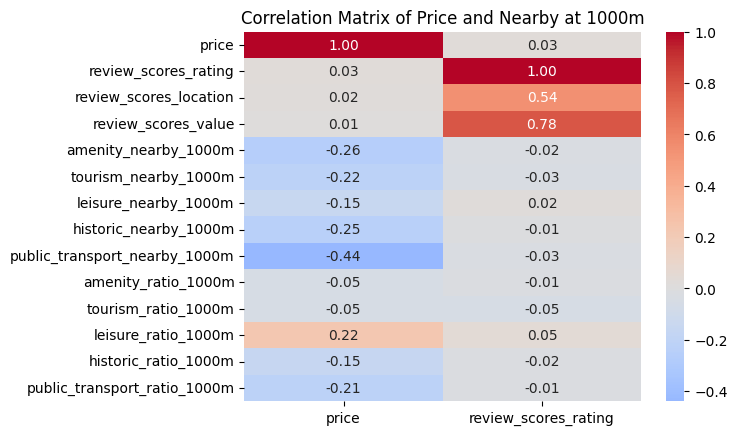

,price,review_scores_rating
price,1.000000,0.031316
review_scores_rating,0.031316,1.000000
review_scores_location,0.017611,0.542997
review_scores_value,0.011974,0.784566
amenity_nearby_1500m,-0.277983,-0.019925
tourism_nearby_1500m,-0.254955,-0.028152
leisure_nearby_1500m,-0.195019,0.018704
historic_nearby_1500m,-0.292002,-0.015107
public_transport_nearby_1500m,-0.452782,-0.021475
amenity_ratio_1500m,-0.064732,-0.018921


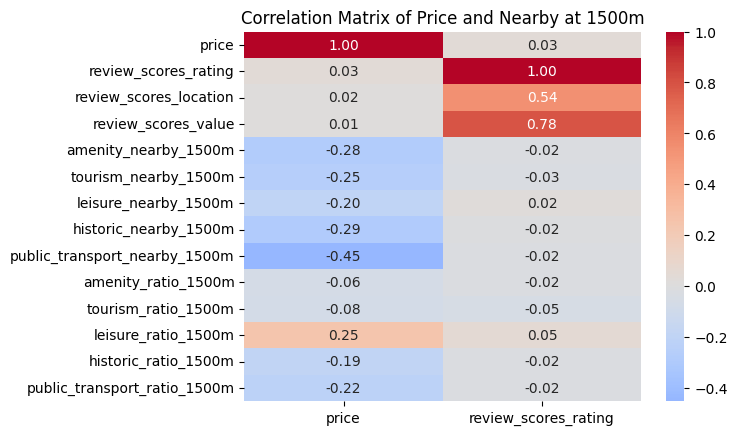

,price,review_scores_rating
price,1.000000,0.031316
review_scores_rating,0.031316,1.000000
review_scores_location,0.017611,0.542997
review_scores_value,0.011974,0.784566
amenity_nearby_2000m,-0.295674,-0.016895
tourism_nearby_2000m,-0.276537,-0.023340
leisure_nearby_2000m,-0.224198,0.018473
historic_nearby_2000m,-0.319188,-0.016731
public_transport_nearby_2000m,-0.458250,-0.019043
amenity_ratio_2000m,-0.088484,-0.019629


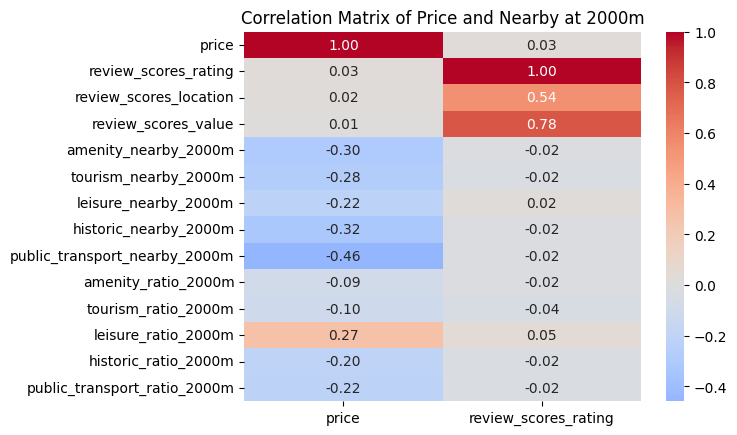

,price,review_scores_rating
price,1.000000,0.031316
review_scores_rating,0.031316,1.000000
review_scores_location,0.017611,0.542997
review_scores_value,0.011974,0.784566
amenity_nearby_2500m,-0.309805,-0.016580
tourism_nearby_2500m,-0.294527,-0.020912
leisure_nearby_2500m,-0.245584,0.018694
historic_nearby_2500m,-0.340136,-0.016292
public_transport_nearby_2500m,-0.459930,-0.020109
amenity_ratio_2500m,-0.095008,-0.023768


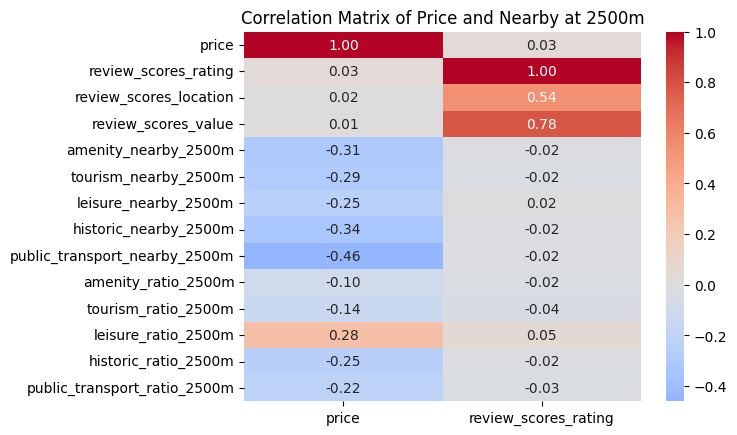

,price,review_scores_rating
price,1.000000,0.031316
review_scores_rating,0.031316,1.000000
review_scores_location,0.017611,0.542997
review_scores_value,0.011974,0.784566
amenity_nearby_3000m,-0.322410,-0.016723
tourism_nearby_3000m,-0.313647,-0.019313
leisure_nearby_3000m,-0.264470,0.018573
historic_nearby_3000m,-0.362344,-0.015333
public_transport_nearby_3000m,-0.462012,-0.018944
amenity_ratio_3000m,-0.103463,-0.026341


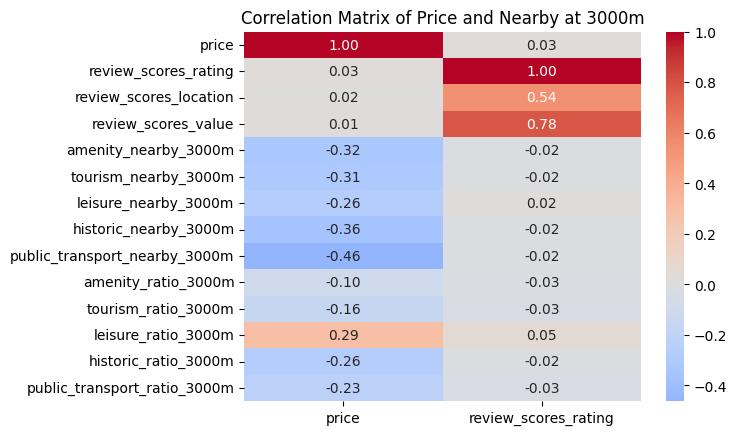

,price,review_scores_rating
price,1.000000,0.031316
review_scores_rating,0.031316,1.000000
review_scores_location,0.017611,0.542997
review_scores_value,0.011974,0.784566
amenity_nearby_3500m,-0.333406,-0.017115
tourism_nearby_3500m,-0.331886,-0.018551
leisure_nearby_3500m,-0.279983,0.018366
historic_nearby_3500m,-0.382450,-0.014864
public_transport_nearby_3500m,-0.464215,-0.018505
amenity_ratio_3500m,-0.111186,-0.026834


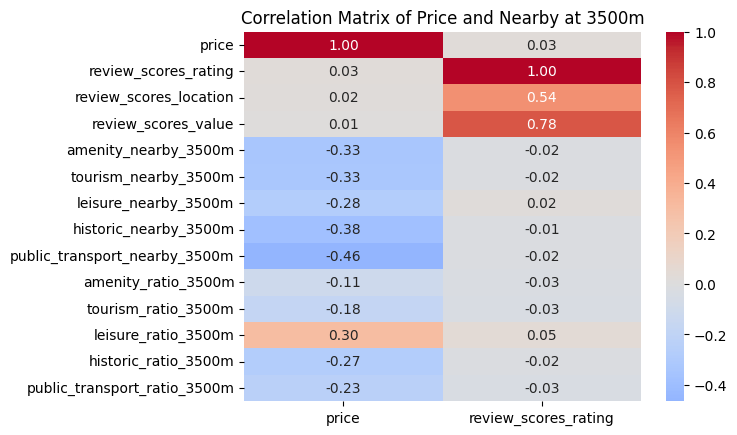

,price,review_scores_rating
price,1.000000,0.031316
review_scores_rating,0.031316,1.000000
review_scores_location,0.017611,0.542997
review_scores_value,0.011974,0.784566
amenity_nearby_4000m,-0.345236,-0.017102
tourism_nearby_4000m,-0.348630,-0.018942
leisure_nearby_4000m,-0.294301,0.017362
historic_nearby_4000m,-0.403312,-0.014213
public_transport_nearby_4000m,-0.469256,-0.018352
amenity_ratio_4000m,-0.117940,-0.029081


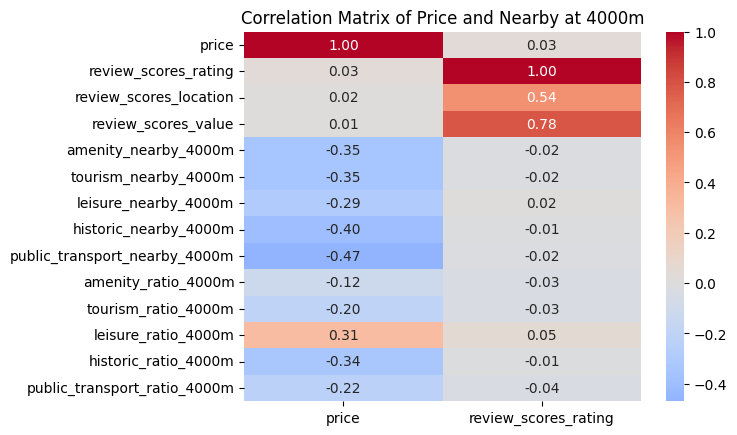

,price,review_scores_rating
price,1.000000,0.031316
review_scores_rating,0.031316,1.000000
review_scores_location,0.017611,0.542997
review_scores_value,0.011974,0.784566
amenity_nearby_4500m,-0.356433,-0.016795
tourism_nearby_4500m,-0.362257,-0.018804
leisure_nearby_4500m,-0.308440,0.016432
historic_nearby_4500m,-0.423068,-0.014306
public_transport_nearby_4500m,-0.476906,-0.018687
amenity_ratio_4500m,-0.121198,-0.029500


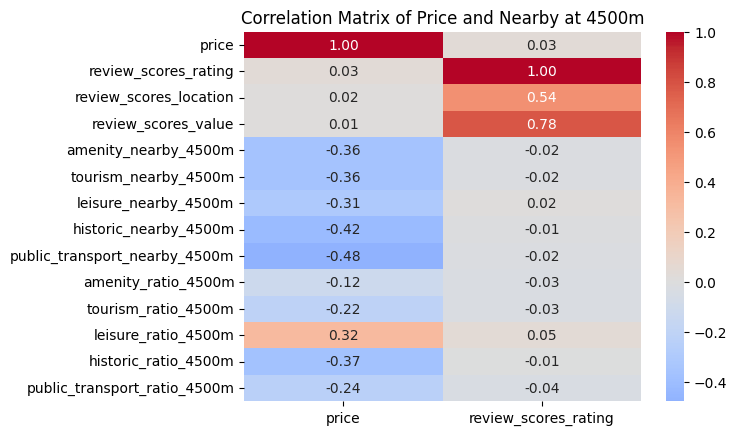

,price,review_scores_rating
price,1.000000,0.031316
review_scores_rating,0.031316,1.000000
review_scores_location,0.017611,0.542997
review_scores_value,0.011974,0.784566
amenity_nearby_5000m,-0.366550,-0.016658
tourism_nearby_5000m,-0.373150,-0.018244
leisure_nearby_5000m,-0.319792,0.015353
historic_nearby_5000m,-0.440417,-0.013673
public_transport_nearby_5000m,-0.487509,-0.018814
amenity_ratio_5000m,-0.126608,-0.029293


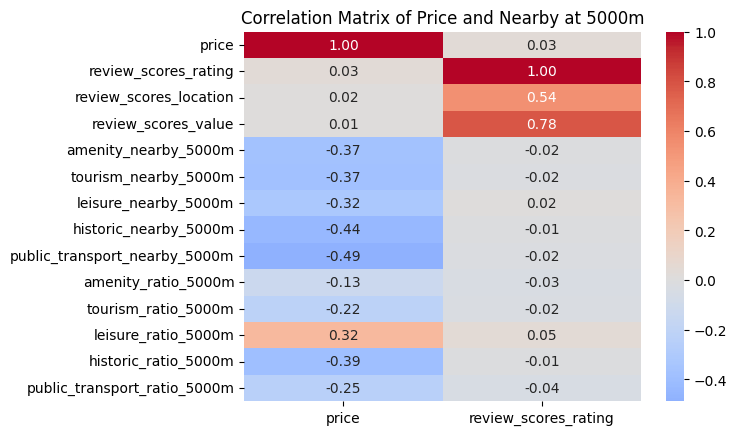

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine as p9
#notes
#correlation values vary from -0.13-0.01
#price - and review_scores_location strongest + correlations

##ai
distances = range(500, 5500, 500)
targets = ["price", "review_scores_rating"]
features = ["amenity", "tourism", "leisure", "historic", "public_transport"]

#counts
trend_data = []

for distance in distances:
    for feature in features:
        corr = air[[f"{feature}_nearby_{distance}m"] + targets].corr().loc[feature+'_nearby_'+str(distance)+'m']
        for target in targets:
            trend_data.append({"distance": distance, "feature": feature, "target": target, "correlation": corr[target]})

df_trends = pd.DataFrame(trend_data)

sns.lineplot(data=df_trends, x="distance", y="correlation", hue="feature", style="target", markers=True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Feature / Target")
plt.title("Correlation Trends with Radius Counts")
plt.show()

## ratios
trend_data = []

for distance in distances:
    for feature in features:
        corr = air[[f"{feature}_ratio_{distance}m"] + targets].corr().loc[feature+'_ratio_'+str(distance)+'m']
        for target in targets:
            trend_data.append({"distance": distance, "feature": feature, "target": target, "correlation": corr[target]})

df_trends = pd.DataFrame(trend_data)

sns.lineplot(data=df_trends, x="distance", y="correlation", hue="feature", style="target", markers=True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Feature / Target")
plt.title("Correlation Trends with Radius Ratios")
plt.show()
##ai


for distance in range(500,5500,500):
        nearby_cols = [f"amenity_nearby_{distance}m", f"tourism_nearby_{distance}m", f"leisure_nearby_{distance}m",
                        f"historic_nearby_{distance}m", f"public_transport_nearby_{distance}m",
                        f"amenity_ratio_{distance}m", f"tourism_ratio_{distance}m", f"leisure_ratio_{distance}m",
                        f"historic_ratio_{distance}m", f"public_transport_ratio_{distance}m"]
        cols_from_air = ["price", "review_scores_rating", "review_scores_location","review_scores_value"]
        cols = cols_from_air + nearby_cols
        corr_matrix = air[cols].corr()[["price", "review_scores_rating"]]
        display(corr_matrix)
        sns.heatmap(corr_matrix,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                center = 0)
        plt.title(f"Correlation Matrix of Price and Nearby at {distance}m")
        plt.show()